<a href="https://colab.research.google.com/github/hina9789/AI-ML-Internship-Tasks/blob/main/ML_task2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Task 2: Predict Future Stock Prices
Problem Statement

Predict the next day’s closing price of a selected stock using historical data (Open, High, Low, Volume).

Install & Import Libraries

In [1]:
!pip install yfinance

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

Step 2: Load Dataset

In [2]:
stock = yf.download("AAPL", start="2020-01-01", end="2024-01-01")
stock.head()

/tmp/ipykernel_3802/997466175.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock = yf.download("AAPL", start="2020-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.400497,72.460761,71.156659,71.409763,135480400
2020-01-03,71.696632,72.455950,71.472454,71.629138,146322800
2020-01-06,72.267914,72.306483,70.568488,70.819186,118387200
2020-01-07,71.928062,72.533103,71.708703,72.277586,108872000
2020-01-08,73.085121,73.386438,71.631567,71.631567,132079200


Data Preprocessing

In [3]:
stock['Target'] = stock['Close'].shift(-1)
stock = stock.dropna()

features = ['Open', 'High', 'Low', 'Volume']
X = stock[features]
y = stock['Target']

Step 4: Train-Test Split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

Step 5: Train Models

linear Regression

In [7]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

Random Forest

In [5]:
rf_model = RandomForestRegressor(n_estimators=100)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

Step 6: Evaluate Models

In [8]:
def evaluate(y_test, pred, name):
    print(f"{name} Results:")
    print("MAE:", mean_absolute_error(y_test, pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))
    print()

evaluate(y_test, lr_pred, "Linear Regression")
evaluate(y_test, rf_pred, "Random Forest")

Linear Regression Results:
MAE: 1.6542229846343908
RMSE: 2.2239488195771044

Random Forest Results:
MAE: 7.498476787206545
RMSE: 10.32561715606399



Plot Actual vs Predicted

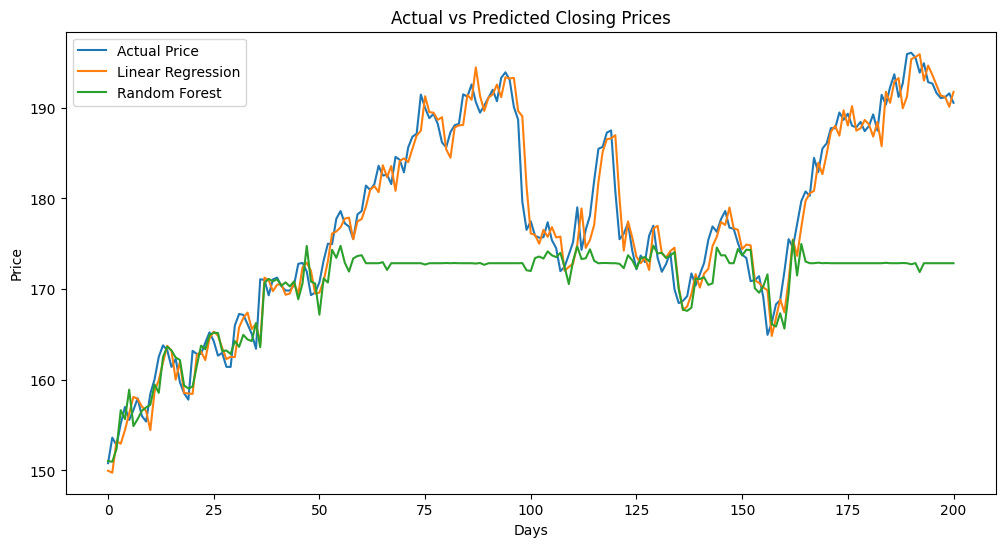

In [9]:
plt.figure(figsize=(12,6))
plt.plot(y_test.values, label="Actual Price")
plt.plot(lr_pred, label="Linear Regression")
plt.plot(rf_pred, label="Random Forest")
plt.legend()
plt.title("Actual vs Predicted Closing Prices")
plt.xlabel("Days")
plt.ylabel("Price")
plt.show()

Data Visualization

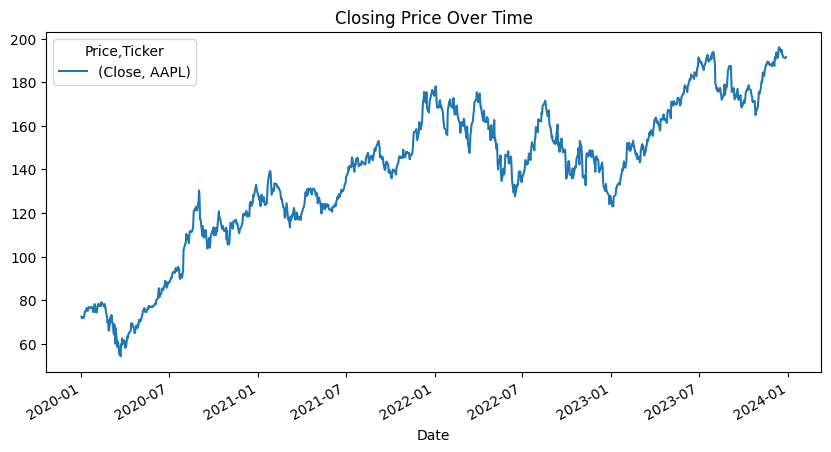

In [10]:
stock[['Close']].plot(figsize=(10,5), title="Closing Price Over Time")
plt.show()

**Explaination :**bold text**
**Model Explanation**
Linear Regression assumes a linear relationship between features and target.
Random Forest captures complex patterns using multiple decision trees.
** Observations**
Random Forest usually performs better for stock data (non-linear patterns).
Predictions follow trend but are not perfect due to market volatility.
**Limitations**
Stock market is unpredictable.
Model does not consider news, sentiment, or macro factors.